In [1]:
import pandas as pd
import numpy as np

In [3]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [8]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [9]:
df.dropna(inplace=True)

In [12]:
df.shape

(714, 3)

In [13]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [14]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [17]:
clf = DecisionTreeClassifier()


In [19]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [20]:
accuracy_score(y_pred,y_test)

0.6223776223776224

In [21]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6331181533646323)

In [23]:
kbin_age = KBinsDiscretizer(n_bins=5,encode='ordinal',strategy='kmeans')
kbin_fare = KBinsDiscretizer(n_bins=5,encode='ordinal',strategy='kmeans')

In [25]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [27]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [ ]:
trf.named_transformers_

{'first': KBinsDiscretizer(encode='ordinal', strategy='kmeans'),
 'second': KBinsDiscretizer(encode='ordinal', strategy='kmeans')}

In [30]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42      , 12.69636862, 27.02765256, 39.35418895, 54.21464646,
              80.        ])                                                   ],
      dtype=object)

In [34]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [35]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                              bins=trf.named_transformers_['first'].bin_edges_[0].tolist())

output['fare_labels'] = pd.cut(x=X_train['Fare'],
                               bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [36]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
437,24.0,1.0,18.75,0.0,"(12.696, 27.028]","(0.0, 42.424]"
302,19.0,1.0,0.00,0.0,"(12.696, 27.028]",NaN
272,41.0,3.0,19.50,0.0,"(39.354, 54.215]","(0.0, 42.424]"
37,21.0,1.0,8.05,0.0,"(12.696, 27.028]","(0.0, 42.424]"
134,25.0,1.0,13.00,0.0,"(12.696, 27.028]","(0.0, 42.424]"


In [37]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [38]:
accuracy_score(y_test,y_pred2)

0.6223776223776224

In [39]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6359154929577465)

In [48]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])

    X_trf = trf.fit_transform(X)

    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")


    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title('Fare')


c:\Users\Mohit Kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\Mohit Kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


0.6288928012519561


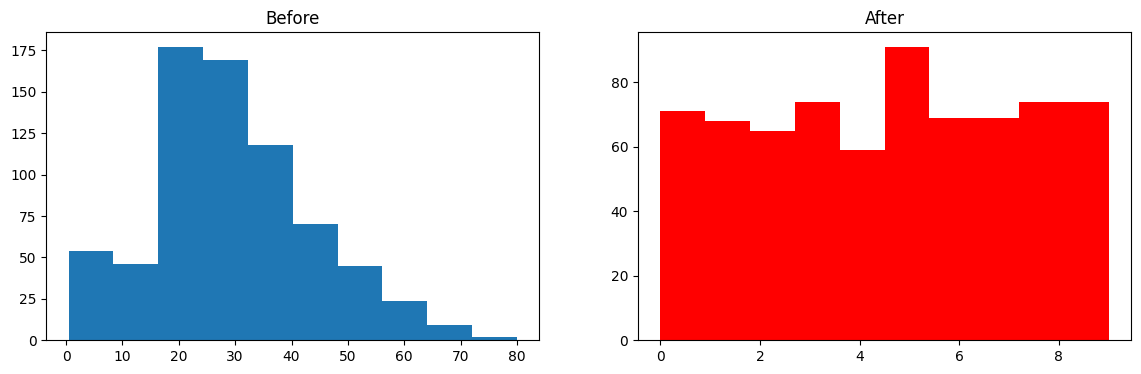

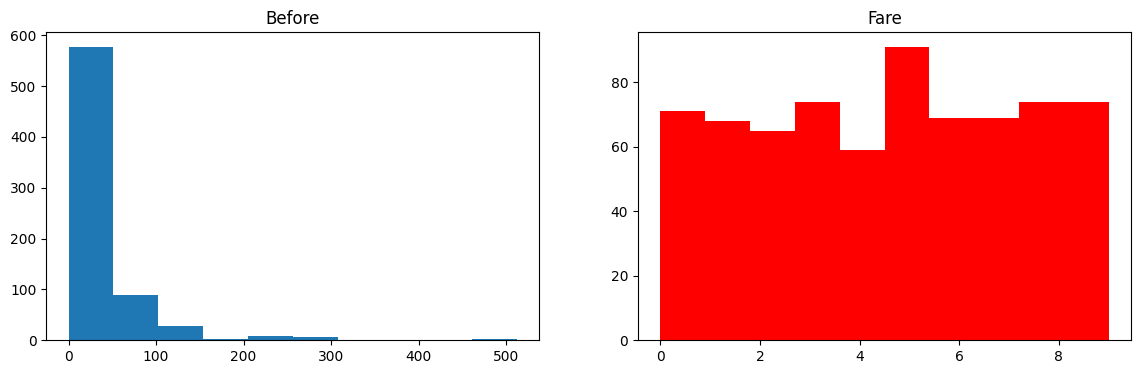

In [49]:
discretize(10,'quantile')